# Agent Evaluation Mini-Case: Why Final-Answer Metrics Miss the Story

**O'Reilly Live Course**: *Statistical Testing for LLM Evaluations*
**Subtitle**: *Design experiments that catch the improvements worth shipping*
**Instructor**: Rudrendu Paul
**Section 4 (10 min). Production Failure Case 2 of 2: The benchmark-production gap (5 min)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RudrenduPaul/statistical-testing-for-llm-evaluations/blob/main/notebooks/04-agent-evaluation-mini-case.ipynb)

---

## What this notebook covers

Evaluating an AI agent is harder than evaluating a single LLM call: agent behavior emerges from tool selection, planning, memory management, and error recovery, and the final answer captures almost none of that.

- This is a simulation. All task records are generated from fixed distributions. The production-constraint penalties used in Section 4 (latency failures, timeouts, and context overflow tied to step count and trajectory efficiency) are coded-in assumptions that build Agent A's drop into the data, so the result illustrates a mechanism and should not be quoted as field data.
- Two agents run on ~200 tasks. Agent A wins on final-answer accuracy through more retries and tool calls, but its success rate drops sharply under production constraints (latency, rate limits, timeouts) while Agent B barely moves.
- A correct answer can come from a broken process, and a wrong answer from a sound process that hit bad input. Final-answer scoring alone can't tell the two apart.

Four sections:
1. **Simulate** agent task execution with realistic multi-level metrics
2. **Expose** the final-answer trap
3. **Apply** multi-level evaluation across trajectory, efficiency, and outcome
4. **Compare** Agent A vs. Agent B under production constraints

---

## Setup

Install dependencies (preinstalled in Colab; the `pip install` is a safety net locally). Standard data science stack (`scipy`, `statsmodels`, `matplotlib`, `numpy`, `pandas`, `seaborn`) on simulated data, no agent framework or LLM API required.

> The setup cell skips the install when the packages import cleanly. Red text during an install means a version conflict, not a failure.

In [1]:
import importlib.util, subprocess, sys
_pkgs = {'scipy': 'scipy', 'statsmodels': 'statsmodels', 'matplotlib': 'matplotlib',
         'numpy': 'numpy', 'pandas': 'pandas', 'seaborn': 'seaborn'}
_missing = [pip_name for mod, pip_name in _pkgs.items() if importlib.util.find_spec(mod) is None]
if _missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + _missing)

---

## Imports and plot configuration

- `np.random.seed(42)` makes the notebook reproducible top to bottom. Change the seed and the numbers shift, but the conclusions should hold.
- `AGENT_A_COLOR` / `AGENT_B_COLOR` are defined once and reused in every chart, so swapping colors (for accessibility, say) means changing two lines, not twenty, a habit that carries straight into production eval dashboards.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# Fix the random seed BEFORE any data generation.
# WHY: Reproducibility is a first-class requirement in eval pipelines.
# A seed-less notebook produces different numbers on every run, making it
# impossible to compare results across team members or across time.
np.random.seed(42)

# ── Plot aesthetics ──────────────────────────────────────────────────────────
# WHY whitegrid: grid lines help readers read off values from bar and line charts
# without needing to trace to the y-axis. The alternative (darkgrid) adds visual
# noise that competes with the data ink.
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,          # high-DPI for projectors and retina screens
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,   # remove chart junk: top and right spines add nothing
    'axes.spines.right': False,
})

# Define agent colors once. Use throughout every chart for visual consistency.
# WHY a warm orange for Agent A and a cool blue for Agent B:
# Warm/cool contrast is intuitive: "hot" Agent A is aggressive/expensive,
# "cool" Agent B is measured/efficient. Avoid red/green (colorblind accessibility).
AGENT_A_COLOR = '#E07B54'   # warm orange, Agent A (brute-force, answer-optimized)
AGENT_B_COLOR = '#4A90D9'   # cool blue, Agent B (efficient, trajectory-optimized)

print('All imports successful.')

All imports successful.


---

## Section 1: Simulating agent task execution

- Agent A hits high final-answer accuracy through brute force (more steps, retries, sloppy tool use) but only works with enough time, compute, and API headroom to keep retrying.
- Agent B lands slightly lower accuracy through a cleaner process, and holds up when that headroom runs short, a gap invisible if you only measure final answers.

**Production scenario (simulated)**: A team ships Agent A (84.5% benchmark task success) over Agent B (81.5%). Under the simulated production constraints in Section 4, Agent A's success rate drops to 70.5% while Agent B holds at 79.5%. Those constraint penalties are assumptions coded into the simulation, so the scenario illustrates a mechanism and should not be quoted as field data.

---

### The five metrics we track

| Metric | Type | What it captures |
|---|---|---|
| `task_success` | Binary 0/1 | Did the agent complete the goal? |
| `num_steps` | Integer 1–8 | How many action steps the agent took |
| `tool_selection_accuracy` | 0–1 | Fraction of steps where the agent picked the right tool |
| `trajectory_efficiency` | 0–1 | Ratio of optimal steps to steps taken |
| `final_answer_quality` | 0–1 | Quality score for the final output |

- **`task_success`**: necessary but not sufficient. 12 flailing tool calls score the same 1 as 3 targeted steps.
- **`num_steps`**: more steps mean more cost, latency, failure surface.
- **`tool_selection_accuracy`**: decision quality at each choice point, not just the final output.
- **`trajectory_efficiency`**: most correlated with production resilience. 0.7 means 43% more steps than necessary.
- **`final_answer_quality`**: the most natural metric to read, and the most likely to mislead in isolation.

**Agent A** is tuned for final answer quality: over-explores, brute-forces its way to an acceptable answer. **Agent B** is tuned for trajectory efficiency: precise tool choices, fewer steps, a slightly weaker answer, a far more reliable process.

> Agent A's `tool_selection_accuracy` mean is 0.63 (1 in 3 tool choices wrong); Agent B's `trajectory_efficiency` mean is 0.79 (~27% more steps than optimal) against Agent A's 0.52. **Discuss**: why is Agent B's `final_answer_quality` slightly lower despite better tool choices and fewer steps? Agent A's extra steps pull in more context and try more strategies, sometimes improving the answer while inflating cost and latency, the trade-off at the heart of this case.

In [3]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# We simulate 200 tasks per agent. Why 200?
# - Large enough that sampling noise does not dominate the results
#   (central limit theorem kicks in reliably around N=30, but 200 gives tight CIs)
# - Small enough that the bootstrap loop in Section 3 runs in seconds
# - Production evals often have 100–500 labeled tasks; 200 is realistic
# ─────────────────────────────────────────────────────────────────────────────
N = 200  # tasks per agent

# ── Agent A: high final-answer quality, poor trajectory efficiency ────────────
# Design intent: Agent A is what you get when you optimize purely for correctness
# during development. It uses a "try everything" strategy: broad tool calls,
# multiple retrieval attempts, extensive context gathering. It works. It just
# works expensively and fragily.
agent_a = pd.DataFrame({
    'agent': 'Agent A',
    'task_id': np.arange(N),

    # task_success ~ Binomial(p=0.84): Agent A completes ~84% of tasks.
    # WHY binomial: task completion is binary (did it succeed or not?).
    # p=0.84 means roughly 1 in 6 tasks fails even in benchmark conditions.
    'task_success': np.random.binomial(1, 0.84, N),

    # num_steps ~ Uniform(4, 8): Agent A takes 4–8 steps per task.
    # WHY 4–8: A simple 3-tool task should take 3 steps; Agent A adds 1–5 extra
    # steps through redundant retries and exploratory tool calls.
    'num_steps': np.random.randint(4, 9, N),          # 4–8 steps: over-explorer

    # tool_selection_accuracy ~ Normal(0.63, 0.12), clipped to [0.2, 0.95].
    # WHY 0.63: Agent A picks the wrong tool ~37% of the time at each step.
    # This is not random guessing (50%): Agent A has some planning ability,
    # but it is far from precise. In practice this means 1 in 3 tool calls is
    # a wasted API call.
    'tool_selection_accuracy': np.clip(
        np.random.normal(0.63, 0.12, N), 0.2, 0.95),

    # trajectory_efficiency ~ Normal(0.52, 0.11), clipped to [0.2, 0.85].
    # WHY 0.52: efficiency of 0.52 means Agent A takes almost twice as many steps
    # as the optimum on average (1/0.52 ≈ 1.92x the minimum required steps).
    # This is the "brute force" signature.
    'trajectory_efficiency': np.clip(
        np.random.normal(0.52, 0.11, N), 0.2, 0.85),

    # final_answer_quality ~ Normal(0.81, 0.09), clipped to [0.4, 0.99].
    # WHY 0.81: despite the inefficient process, Agent A's final answers are
    # good. The extra tool calls and context gathering do improve output quality,
    # which is why final-answer-only metrics make it look like the winner.
    'final_answer_quality': np.clip(
        np.random.normal(0.81, 0.09, N), 0.4, 0.99),
})

# ── Agent B: slightly lower final-answer, much better trajectories ────────────
# Design intent: Agent B is what you get when you optimize for process quality.
# It uses a "plan first, act precisely" strategy: fewer tool calls, targeted
# retrieval, minimal retries. Its final answers are slightly weaker because
# it commits to fewer retrieval attempts and stops when it has enough information.
agent_b = pd.DataFrame({
    'agent': 'Agent B',
    'task_id': np.arange(N),

    # task_success ~ Binomial(p=0.81): Agent B completes ~81% of tasks.
    # WHY 0.81 vs Agent A's 0.84: a 3-point gap in benchmark success rates.
    # This is the number that would make a naive team choose Agent A.
    'task_success': np.random.binomial(1, 0.81, N),

    # num_steps ~ Uniform(2, 5): Agent B takes 2–5 steps per task.
    # WHY 2–5: efficient agents can often complete a simple task in 2–3 steps.
    # Even for complex tasks, Agent B rarely needs more than 5.
    'num_steps': np.random.randint(2, 6, N),           # 2–5 steps: efficient

    # tool_selection_accuracy ~ Normal(0.84, 0.08), clipped to [0.55, 0.99].
    # WHY 0.84: Agent B picks the right tool ~84% of the time. This is not
    # perfect, but it means only 1 in 6 tool choices is wrong, compared to
    # Agent A's 1 in 3.
    'tool_selection_accuracy': np.clip(
        np.random.normal(0.84, 0.08, N), 0.55, 0.99),

    # trajectory_efficiency ~ Normal(0.79, 0.09), clipped to [0.5, 0.99].
    # WHY 0.79: Agent B takes about 27% more steps than the theoretical optimum
    # (1/0.79 ≈ 1.27x). Much better than Agent A's 1.92x, but still imperfect.
    'trajectory_efficiency': np.clip(
        np.random.normal(0.79, 0.09, N), 0.5, 0.99),

    # final_answer_quality ~ Normal(0.75, 0.10), clipped to [0.4, 0.99].
    # WHY 0.75 vs Agent A's 0.81: a 6-point gap in final answer quality.
    # This is the metric that makes Agent A look better on benchmarks.
    # The key question this notebook answers: is 6 points of answer quality
    # worth the process fragility? (Spoiler: for most production systems, no.)
    'final_answer_quality': np.clip(
        np.random.normal(0.75, 0.10, N), 0.4, 0.99),
})

# Combine into a single DataFrame for analysis
df = pd.concat([agent_a, agent_b], ignore_index=True)

# ── Print summary statistics ──────────────────────────────────────────────────
# WHY this summary table: always look at the raw numbers before plotting.
# Plots compress information; the table shows the values we will reference
# throughout the rest of the notebook.
summary = df.groupby('agent').agg(
    task_success_rate=('task_success', 'mean'),
    avg_steps=('num_steps', 'mean'),
    tool_selection_accuracy=('tool_selection_accuracy', 'mean'),
    trajectory_efficiency=('trajectory_efficiency', 'mean'),
    final_answer_quality=('final_answer_quality', 'mean'),
).round(3)

print('Simulated data summary:')
print(summary.to_string())

# ── What to look for in this output ──────────────────────────────────────────
# Agent A wins on: final_answer_quality (by ~0.06)
# Agent B wins on: tool_selection_accuracy (~0.21 higher), trajectory_efficiency (~0.27 higher)
# Both are close on: task_success_rate (~0.03 gap)
# Agent A avg_steps is ~1.5–2x Agent B avg_steps
#
# If your team only looks at task_success_rate and final_answer_quality,
# you will ship Agent A. The next two sections show why that is a mistake.

Simulated data summary:
         task_success_rate  avg_steps  tool_selection_accuracy  trajectory_efficiency  final_answer_quality
agent                                                                                                      
Agent A              0.845      6.035                    0.633                  0.515                 0.816
Agent B              0.815      3.505                    0.845                  0.800                 0.755


---

## Section 2: The final-answer trap

- Scored only on final answers, Agent A wins: a brute-force solver that looks strong on benchmarks (unlimited time and compute), conditions production doesn't offer.
- Typical failure: a team ships the benchmark winner, then watches production success collapse once latency spikes, rate limits kick in, or context windows fill up.
- Scoring only the final output misses:
  - Redundant tool calls padding the path to a correct answer
  - Agents that break without warning on tasks needing precise tool sequencing
  - Answer quality that degrades gracefully while token spend explodes

We run a two-proportion z-test on `final_answer_quality` (binarized at the median) to show Agent A "wins" the standard eval, then why that conclusion is wrong. Note that this tests a binarized metric: the median split discards the size of each score gap, so the z-value reflects how many answers fall above one cutoff and says nothing about the 0.06 difference in mean quality.

> One-sided z-test: H0 is equal high-quality rates, H1 is Agent A > Agent B, p < 0.05 rejects H0. The statistics are correct; the metric is the problem. "Better" here means better on this metric, under this test condition, not in production.

### What "winning" means

The z-test shows Agent A with a significant edge. A team that stops here ships Agent A. Three months later, when API latency spikes, Agent A's retry-heavy strategy blows past timeouts and its success rate collapses. Agent A does produce better answers under ideal conditions; those conditions aren't production conditions.

In [4]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# This cell replicates the most common agent evaluation mistake: binarize the
# final answer quality score at a threshold, then run a statistical test.
# The test is methodologically sound. The mistake is treating its result as
# the full picture.
# ─────────────────────────────────────────────────────────────────────────────

# Binarize final_answer_quality at the overall median.
# WHY the overall median (not a fixed threshold like 0.75)?
# Using the population median makes this a fair comparison: we classify the
# top 50% of *all* answers as "high quality", regardless of which agent produced
# them. A fixed threshold would embed a judgment about what "good" means;
# the median lets the data define the threshold. In practice, teams should
# calibrate their threshold to business requirements (e.g., "any score below
# 0.7 is unacceptable for a customer-facing response").
quality_threshold = df['final_answer_quality'].median()

# Create binary "high quality" indicator for each agent's tasks
# 1 = answer is at or above the quality threshold; 0 = below threshold
df['high_quality_answer'] = (df['final_answer_quality'] >= quality_threshold).astype(int)

a_hq = agent_a['final_answer_quality'].apply(lambda x: 1 if x >= quality_threshold else 0)
b_hq = agent_b['final_answer_quality'].apply(lambda x: 1 if x >= quality_threshold else 0)

# Count how many tasks each agent produced "high quality" answers for
count_hq = np.array([a_hq.sum(), b_hq.sum()])
nobs = np.array([N, N])

# ── Two-proportion z-test ─────────────────────────────────────────────────────
# WHY a z-test for proportions (not a t-test, not chi-squared)?
# - We are comparing two binary proportions (fraction of "high quality" answers)
# - The z-test for proportions is the standard test for this: it tests whether
#   the two underlying population proportions are equal under H0
# - alternative='larger' = one-sided test: H1 is "Agent A proportion > Agent B"
# - We use one-sided because the team's specific belief is "A is better than B",
#   not just "A and B are different". One-sided tests have more power for
#   detecting a specific directional effect.
z_stat, p_val = proportions_ztest(count_hq, nobs, alternative='larger')

print('=== Final-Answer-Only Evaluation ===')
print(f'Quality threshold (median): {quality_threshold:.3f}')
print(f'Agent A: {count_hq[0]}/{N} tasks above threshold ({count_hq[0]/N:.1%})')
print(f'Agent B: {count_hq[1]}/{N} tasks above threshold ({count_hq[1]/N:.1%})')
print(f'\nTwo-proportion z-test (H1: Agent A > Agent B):')
print(f'  z = {z_stat:.3f}, p = {p_val:.4f}')

# ── Interpret the z-test result ───────────────────────────────────────────────
# z > 1.645 and p < 0.05: we reject H0. Agent A "wins" the final-answer eval.
# This is not a statistical error. Agent A does produce higher-quality
# answers more frequently. The error is treating this as the complete verdict.
if p_val < 0.05:
    print('  Result: Agent A is significantly better (p < 0.05).')
    print('  Naive conclusion: Ship Agent A.')
    print()
    print('  WHY THIS IS WRONG: The z-test is answering the right question')
    print('  about the wrong metric. Final answer quality measures output.')
    print('  It says nothing about how much that output cost, how many steps')
    print('  it took, or whether the process will hold up under load.')
else:
    print('  Result: No significant difference detected.')

# ── Show what the final-answer metric hides ───────────────────────────────────
# WHY print this table: the contrast between the "naive conclusion" above
# and the full picture below is the pedagogical core of this section.
# Students should feel the gap between what the standard eval tells them
# and what the data contains.
print('\n=== What the final-answer metric hides ===')
comparison = pd.DataFrame({
    'Metric': ['Final answer quality', 'Avg steps per task', 'Tool selection accuracy', 'Trajectory efficiency'],
    'Agent A': [
        f"{agent_a['final_answer_quality'].mean():.3f}",
        f"{agent_a['num_steps'].mean():.1f} steps",   # MORE steps = MORE cost
        f"{agent_a['tool_selection_accuracy'].mean():.3f}",
        f"{agent_a['trajectory_efficiency'].mean():.3f}",
    ],
    'Agent B': [
        f"{agent_b['final_answer_quality'].mean():.3f}",
        f"{agent_b['num_steps'].mean():.1f} steps",   # FEWER steps = LESS cost
        f"{agent_b['tool_selection_accuracy'].mean():.3f}",
        f"{agent_b['trajectory_efficiency'].mean():.3f}",
    ],
    'Better agent': [
        'Agent A (marginally)',
        'Agent B (fewer steps)',    # Each extra step = extra API call = extra $
        'Agent B (much higher)',    # Better tool selection = fewer wasted calls
        'Agent B (much higher)',    # Higher efficiency = more resilient under constraints
    ]
})
print(comparison.to_string(index=False))
print()
print('Agent A consumes more tokens and selects wrong tools more often.')
print('A final-answer metric alone would ship the wrong agent.')
print()
# Quantify the step cost gap explicitly so students can anchor to a dollar figure
avg_steps_a = agent_a['num_steps'].mean()
avg_steps_b = agent_b['num_steps'].mean()
step_ratio = avg_steps_a / avg_steps_b
print(f'Step ratio: Agent A takes {step_ratio:.1f}x as many steps as Agent B on average.')
print(f'If each LLM call costs $0.01 (illustrative assumption), Agent A costs ${step_ratio * 0.01:.3f} vs Agent B ${0.01:.3f} per task (relative cost, Agent B normalized to one call).')
print(f'At 10,000 tasks/day, that is ${(avg_steps_a - avg_steps_b) * 0.01 * 10000:,.0f}/day in extra API cost.')

=== Final-Answer-Only Evaluation ===
Quality threshold (median): 0.783
Agent A: 123/200 tasks above threshold (61.5%)
Agent B: 77/200 tasks above threshold (38.5%)

Two-proportion z-test (H1: Agent A > Agent B):
  z = 4.600, p = 0.0000
  Result: Agent A is significantly better (p < 0.05).
  Naive conclusion: Ship Agent A.

  WHY THIS IS WRONG: The z-test is answering the right question
  about the wrong metric. Final answer quality measures output.
  It says nothing about how much that output cost, how many steps
  it took, or whether the process will hold up under load.

=== What the final-answer metric hides ===
                 Metric   Agent A   Agent B          Better agent
   Final answer quality     0.816     0.755  Agent A (marginally)
     Avg steps per task 6.0 steps 3.5 steps Agent B (fewer steps)
Tool selection accuracy     0.633     0.845 Agent B (much higher)
  Trajectory efficiency     0.515     0.800 Agent B (much higher)

Agent A consumes more tokens and selects wrong 

### Distribution comparison: what the naive eval sees vs. what it ignores

- **Left chart (final answer quality)**: the naive eval's view. Agent A shifts right, but the two distributions overlap heavily, an edge that's narrow, not dominant.
- **Right chart (steps per task)**: what the naive eval ignores. Agent A spreads across 4–8 steps, Agent B clusters at 2–5, barely touching. Every extra step is another API call, more latency, more failure surface.

> Step-count separation predicts production behavior far better than the answer-quality overlap does, yet most people asked to pick one chart reach for the left one.

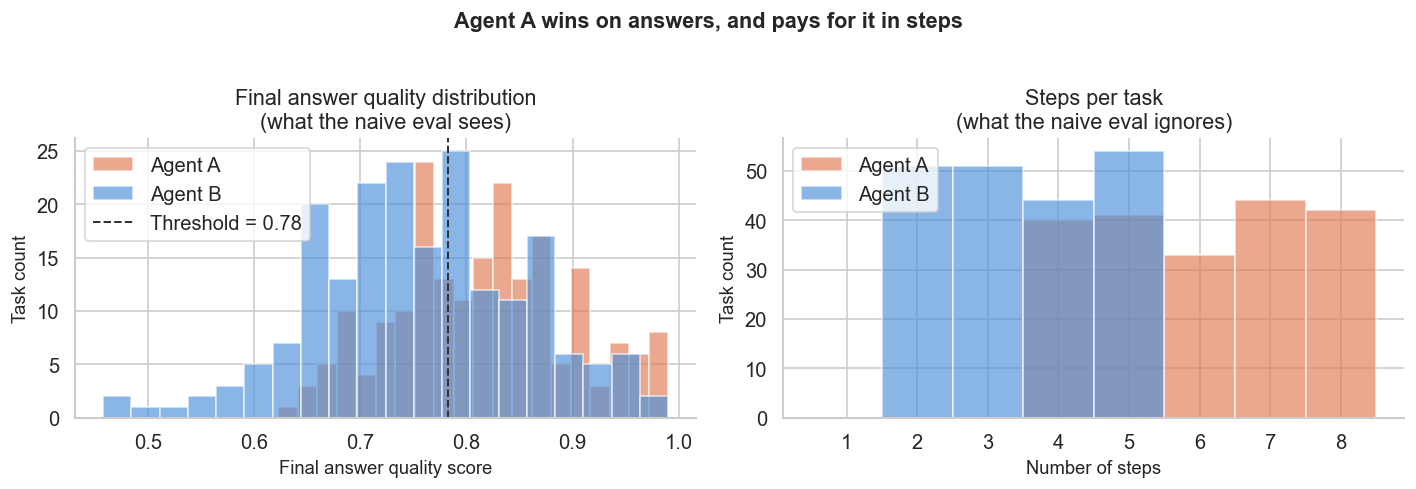

In [5]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# Two side-by-side histograms that visualize the core tension of Section 2:
# Agent A wins on the metric teams typically measure (left chart),
# while Agent B wins on the metric that predicts production cost and resilience
# (right chart). The visual contrast is designed to be jarring.
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left chart: final_answer_quality distributions ───────────────────────────
# WHY histograms instead of box plots?
# Histograms show the full shape of the distribution: where scores cluster,
# whether the distribution is skewed, where the tails are. Box plots compress
# this to five numbers and hide multi-modality. For teaching, the full shape
# matters: students should see that both agents produce a wide spread of answer
# qualities, not just a mean difference.
axes[0].hist(
    agent_a['final_answer_quality'], bins=20, alpha=0.65,
    color=AGENT_A_COLOR, label='Agent A', edgecolor='white')
axes[0].hist(
    agent_b['final_answer_quality'], bins=20, alpha=0.65,
    color=AGENT_B_COLOR, label='Agent B', edgecolor='white')

# Mark the binarization threshold used in the z-test above.
# WHY show the threshold: it makes the z-test visual. Students can see
# that Agent A has more mass above the threshold (right of the dashed line).
axes[0].axvline(quality_threshold, color='#333', linestyle='--', linewidth=1.2,
                label=f'Threshold = {quality_threshold:.2f}')
axes[0].set_title('Final answer quality distribution\n(what the naive eval sees)')
axes[0].set_xlabel('Final answer quality score')
axes[0].set_ylabel('Task count')
axes[0].legend()
# What to look for: Agent A's distribution is shifted right.
# The gap is measurable but the distributions overlap substantially.

# ── Right chart: steps per task ───────────────────────────────────────────────
# WHY align='left' on the histogram?
# Step counts are integers (3, 4, 5...). align='left' places each bar so it
# starts at the integer value, making it visually clear that we are counting
# discrete events, not binning a continuous variable.
axes[1].hist(
    agent_a['num_steps'], bins=range(1, 10), alpha=0.65,
    color=AGENT_A_COLOR, label='Agent A', edgecolor='white', align='left')
axes[1].hist(
    agent_b['num_steps'], bins=range(1, 10), alpha=0.65,
    color=AGENT_B_COLOR, label='Agent B', edgecolor='white', align='left')
axes[1].set_title('Steps per task\n(what the naive eval ignores)')
axes[1].set_xlabel('Number of steps')
axes[1].set_ylabel('Task count')
axes[1].set_xticks(range(1, 9))
axes[1].legend()
# What to look for: almost no overlap between the two distributions.
# Agent B is concentrated at 2–5; Agent A at 4–8.
# This separation is larger and more systematic than the quality gap.
# In production, the step count gap is what causes Agent A to fail under load.

plt.suptitle('Agent A wins on answers, and pays for it in steps',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Section 3: Multi-level agent evaluation

- One metric gives one axis. Agent quality is multi-dimensional: an agent can excel at tool selection and fail badly at path planning. Agent A wins `final_answer_quality` (via over-retrieval); Agent B wins `tool_selection_accuracy` and `trajectory_efficiency`, staying competitive on `task_success`. The radar chart shows Agent A's shape as lopsided, Agent B's as balanced.
- **The practical question**: an agent completing ~84% of tasks but costing ~1.7x as much and breaking under load, or one completing ~82%, costing less, and staying stable? Most production teams at scale should pick Agent B.

---

### Why bootstrap for the trajectory efficiency CI?

- `trajectory_efficiency` is a bounded ratio (0–1) with asymmetric tails; parametric tests (t-test, z-test) assume a normality that this breaks.
- Bootstrap makes no distributional assumption: it resamples the data and reads CIs off the empirical percentiles. Reach for it whenever a metric's distribution is unknown.

---

### Four evaluation levels, at minimum

| Level | Question it answers |
|---|---|
| Task completion | Did the agent achieve the stated goal? |
| Tool use quality | Did the agent pick the right tool at each step? |
| Trajectory efficiency | Did the agent reach the goal via the shortest rational path? |
| Final answer quality | How good is the output the user sees? |

Across all four levels, Agent B wins two of four (tool selection and trajectory efficiency). Agent A wins task success and final answer quality. Agent A's ~6-point edge on final answer quality (and a ~3-point task-success lead that is not statistically significant, see the test in the next cell) costs it 70%+ more steps and worse tool selection.

> Agent A's radar shape: strong on final answer quality, collapsed on tool selection and trajectory efficiency, an agent papering over bad planning with more computation. Agent B's shape: smaller but symmetric, predictable quality. Predictability is a production property; benchmarks reward peak performance, production demands consistency. Fine-tuning Agent A toward efficiency would need trajectory-quality labels that don't exist if the pipeline never measured trajectory efficiency, which is why the eval framework comes before the fine-tuning strategy.

In [6]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# This cell computes the full four-metric comparison and then runs a bootstrap
# CI on the most important differentiating metric: trajectory efficiency.
# We deliberately compute the comparison table first (before the charts) so
# students have numbers to refer to when reading the visual.
# ─────────────────────────────────────────────────────────────────────────────

# The four evaluation levels, in order from "most commonly measured" to
# "most predictive of production resilience"
metrics = ['task_success', 'tool_selection_accuracy', 'trajectory_efficiency', 'final_answer_quality']
metric_labels = ['Task success rate', 'Tool selection accuracy', 'Trajectory efficiency', 'Final answer quality']

# Compute mean scores for each metric for each agent
means_a = [agent_a[m].mean() for m in metrics]
means_b = [agent_b[m].mean() for m in metrics]

print('=== Multi-level evaluation: Agent A vs Agent B ===')
print(f'{"Metric":<28} {"Agent A":>10} {"Agent B":>10} {"Winner":>14}')
print('-' * 66)
for label, ma, mb in zip(metric_labels, means_a, means_b):
    winner = 'Agent A' if ma > mb else 'Agent B'
    # Mark the magnitude of the gap: small vs large differences matter
    gap = abs(ma - mb)
    gap_label = '(marginal)' if gap < 0.05 else '(significant)' if gap > 0.10 else '(moderate)'
    print(f'{label:<28} {ma:>10.3f} {mb:>10.3f} {winner:>14}  {gap_label}')

# ── Bootstrap CI for trajectory efficiency difference ─────────────────────────
# WHY bootstrap (not t-test)?
# trajectory_efficiency is bounded [0, 1] and skewed, the t-test assumes
# normality, which breaks down for bounded ratio metrics. Bootstrap is
# distribution-free: it makes no assumptions about the underlying distribution.
#
# Procedure:
# 1. Draw N samples WITH REPLACEMENT from Agent A's trajectory efficiency values
# 2. Draw N samples WITH REPLACEMENT from Agent B's trajectory efficiency values
# 3. Compute the difference in means: Agent B mean - Agent A mean
# 4. Repeat 5000 times to build a sampling distribution of the difference
# 5. The 2.5th and 97.5th percentiles give the 95% CI
#
# WHY 5000 iterations?
# The CI estimate stabilizes well before 5000 for N=200 samples.
# More iterations = smoother distribution but diminishing returns after ~2000.
# 5000 is a conventional choice that runs in <1 second for this sample size.
z_ts, p_ts = proportions_ztest(
    [int(agent_a['task_success'].sum()), int(agent_b['task_success'].sum())], [N, N])
print(f'\nTask success, Agent A vs Agent B (two-sided two-proportion z-test): z = {z_ts:.3f}, p = {p_ts:.4f}')
print('  Agent A\'s benchmark task-success lead is small and not statistically significant.')

n_boot = 5000
boot_diffs = np.empty(n_boot)   # pre-allocate for speed (vs appending)

traj_a = agent_a['trajectory_efficiency'].values
traj_b = agent_b['trajectory_efficiency'].values

for i in range(n_boot):
    # replace=True is what makes this bootstrap: we sample with replacement
    # from the OBSERVED data. Each bootstrap sample simulates a possible
    # dataset we could have observed given the same underlying distribution.
    boot_a = np.random.choice(traj_a, size=N, replace=True).mean()
    boot_b = np.random.choice(traj_b, size=N, replace=True).mean()
    boot_diffs[i] = boot_b - boot_a  # positive value = Agent B is more efficient

# Percentile CI: read the 2.5th and 97.5th percentiles of the bootstrap
# distribution directly. If the entire CI is above zero, we are 95% confident
# the true difference is positive (Agent B is more efficient).
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
observed_diff = traj_b.mean() - traj_a.mean()

print('\n=== Bootstrap CI: trajectory efficiency (Agent B - Agent A) ===')
print(f'Observed difference:        {observed_diff:+.4f}')
print(f'  Interpretation: Agent B is {observed_diff:.4f} more trajectory-efficient on average.')
print(f'  In step terms: Agent A takes {1/traj_a.mean():.1f}x the optimal step count, Agent B takes {1/traj_b.mean():.1f}x.')
print(f'95% bootstrap CI:           [{ci_low:+.4f}, {ci_high:+.4f}]')

if ci_low > 0:
    print('Conclusion: Agent B is significantly more trajectory-efficient.')
    print('  The CI excludes zero: we are 95% confident the gap is not due to')
    print('  sampling noise. This is the evidence needed to prefer Agent B.')
else:
    print('Conclusion: Difference is not statistically significant.')
    print('  The CI crosses zero: we cannot rule out that this is sampling noise.')

=== Multi-level evaluation: Agent A vs Agent B ===
Metric                          Agent A    Agent B         Winner
------------------------------------------------------------------
Task success rate                 0.845      0.815        Agent A  (marginal)
Tool selection accuracy           0.633      0.845        Agent B  (significant)
Trajectory efficiency             0.515      0.800        Agent B  (significant)
Final answer quality              0.816      0.755        Agent A  (moderate)

Task success, Agent A vs Agent B (two-sided two-proportion z-test): z = 0.799, p = 0.4245
  Agent A's benchmark task-success lead is small and not statistically significant.



=== Bootstrap CI: trajectory efficiency (Agent B - Agent A) ===
Observed difference:        +0.2846
  Interpretation: Agent B is 0.2846 more trajectory-efficient on average.
  In step terms: Agent A takes 1.9x the optimal step count, Agent B takes 1.3x.
95% bootstrap CI:           [+0.2652, +0.3050]
Conclusion: Agent B is significantly more trajectory-efficient.
  The CI excludes zero: we are 95% confident the gap is not due to
  sampling noise. This is the evidence needed to prefer Agent B.


### Radar chart and grouped bar chart: the full multi-level picture

- **Radar chart (left)**: places both agents across all four dimensions at once. Agent A's shape is lopsided (strong on final answer quality, weaker on tool selection and trajectory efficiency); Agent B's is balanced.
- **Grouped bar chart (right)**: precise labeled values, for a technical review or a post-incident report.

> Agent A's asymmetric polygon signals fragility: optimized along one dimension at the expense of the others, the same imbalance behind production failures once an unoptimized constraint (latency, timeout, context) activates. The goal isn't maximum polygon area, it's a shape that stays stable under production constraints.

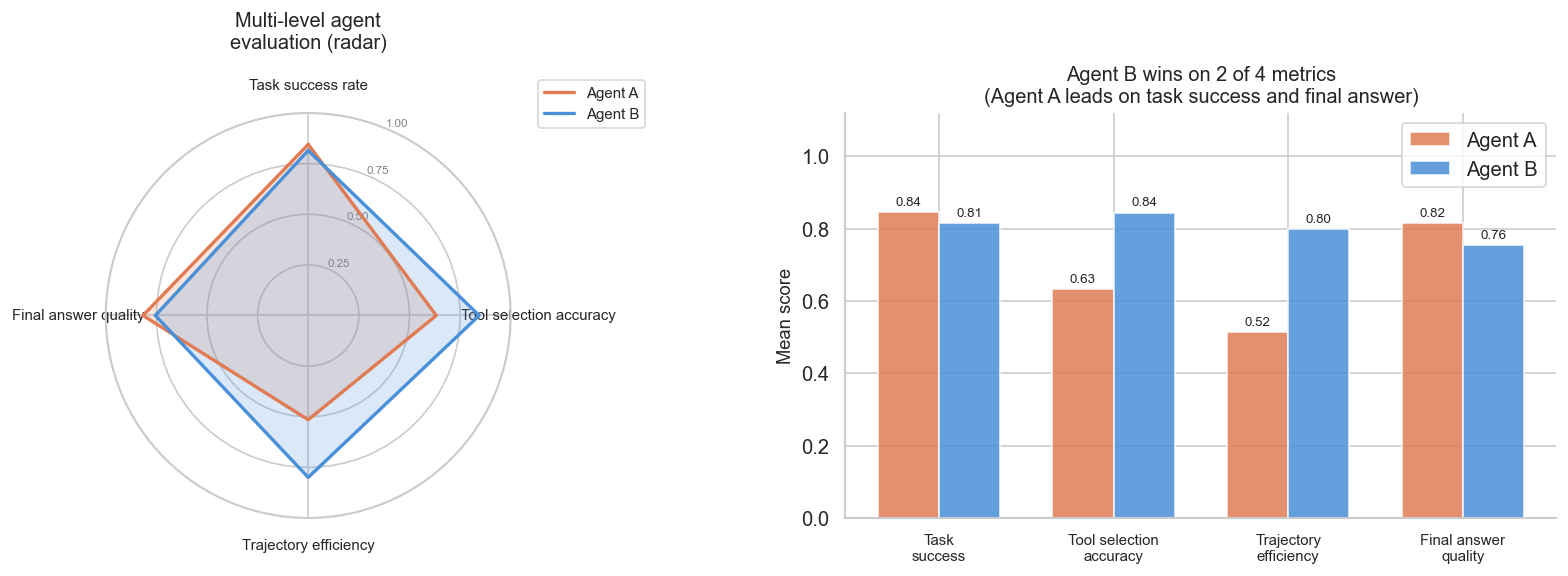

In [7]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# Two charts that present the multi-level comparison in complementary ways:
# 1. Radar: shape communicates balance/imbalance across dimensions
# 2. Grouped bar: precise numbers for direct comparison and reporting
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Radar / spider chart ────────────────────────────────────────────────
# WHY a polar subplot alongside a standard axes array?
# matplotlib's subplot system creates flat (non-polar) axes by default.
# We have to: (a) create a placeholder flat axis in the array, (b) add a new
# polar axis at the same position, (c) delete the flat placeholder.
# This is awkward but necessary: polar projections require explicit creation.
ax_radar = fig.add_subplot(121, polar=True)
fig.delaxes(axes[0])  # remove the flat placeholder

num_metrics = len(metrics)

# Build the angle positions for each metric axis.
# np.linspace(0, 2π, num_metrics, endpoint=False) creates evenly-spaced angles.
# We do NOT include the endpoint because it would duplicate the first angle.
# The final "+ angles[:1]" closes the polygon back to the start point.
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

# Extend the metric values to close the polygon (last point = first point)
vals_a = means_a + means_a[:1]
vals_b = means_b + means_b[:1]

# Start at top (π/2 offset), go clockwise (direction=-1)
# WHY clockwise: matches the reading convention for most audiences
ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metric_labels, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_radar.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7, color='grey')

# Plot Agent A: line + filled polygon with low alpha for transparency
ax_radar.plot(angles, vals_a, color=AGENT_A_COLOR, linewidth=2, label='Agent A')
ax_radar.fill(angles, vals_a, color=AGENT_A_COLOR, alpha=0.20)
# What to look for: Agent A's polygon is large on the final_answer_quality axis
# but collapses noticeably on tool_selection_accuracy and trajectory_efficiency.

# Plot Agent B: line + filled polygon
ax_radar.plot(angles, vals_b, color=AGENT_B_COLOR, linewidth=2, label='Agent B')
ax_radar.fill(angles, vals_b, color=AGENT_B_COLOR, alpha=0.20)
# What to look for: Agent B's polygon is more symmetric: no axis where it is
# dramatically stronger or dramatically weaker than the others.

ax_radar.set_title('Multi-level agent\nevaluation (radar)', fontsize=12, pad=18)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

# ── Right: Grouped bar chart ──────────────────────────────────────────────────
# WHY grouped bars (not stacked, not separate charts)?
# Grouped bars allow direct visual comparison of Agent A vs Agent B on each
# metric. Stacked bars would imply the metrics sum to something meaningful
# (they don't). Separate charts would require students to mentally compare
# across pages, so the grouping does that work visually.
ax_bar = axes[1]
x = np.arange(num_metrics)
width = 0.35  # bar width; 0.35 leaves a small gap between the two agent bars

bars_a = ax_bar.bar(x - width/2, means_a, width, color=AGENT_A_COLOR,
                    alpha=0.85, label='Agent A', edgecolor='white')
bars_b = ax_bar.bar(x + width/2, means_b, width, color=AGENT_B_COLOR,
                    alpha=0.85, label='Agent B', edgecolor='white')

# Add value labels above each bar for precise reading
# WHY +0.01 offset: just enough clearance above the bar top to be readable
# without overlapping the bar itself
for bar in bars_a:
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars_b:
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(
    ['Task\nsuccess', 'Tool selection\naccuracy', 'Trajectory\nefficiency', 'Final answer\nquality'],
    fontsize=9)
ax_bar.set_ylim(0, 1.12)
ax_bar.set_ylabel('Mean score')
ax_bar.set_title('Agent B wins on 2 of 4 metrics\n(Agent A leads on task success and final answer)', fontsize=12)
ax_bar.legend()
# What to look for: Agent B's bars are taller on the first three metrics
# (left side). Agent A's bar is taller only on the rightmost metric.
# The three metrics Agent B wins on are the ones that predict production
# behavior. The one metric Agent A wins on is the one that drives benchmark scores.

plt.tight_layout()
plt.show()

### Bootstrap confidence interval: is Agent B's trajectory advantage meaningful or noise?

Empirical sampling distribution of the trajectory efficiency difference (Agent B minus Agent A), from 5,000 bootstrap samples.

- Vertical black line: the observed difference
- Red dashed lines: 2.5th/97.5th percentiles, the 95% CI bounds
- Grey dotted line at 0: "no difference"

If both red lines sit right of zero, the CI is entirely positive: Agent B is more efficient across the underlying population of tasks, not merely this sample. The advantage is structural, not noise.

> The bootstrap distribution comes out roughly bell-shaped by the central limit theorem: the sampling distribution of the mean converges to normal regardless of the underlying shape, given enough N (200 is plenty here).

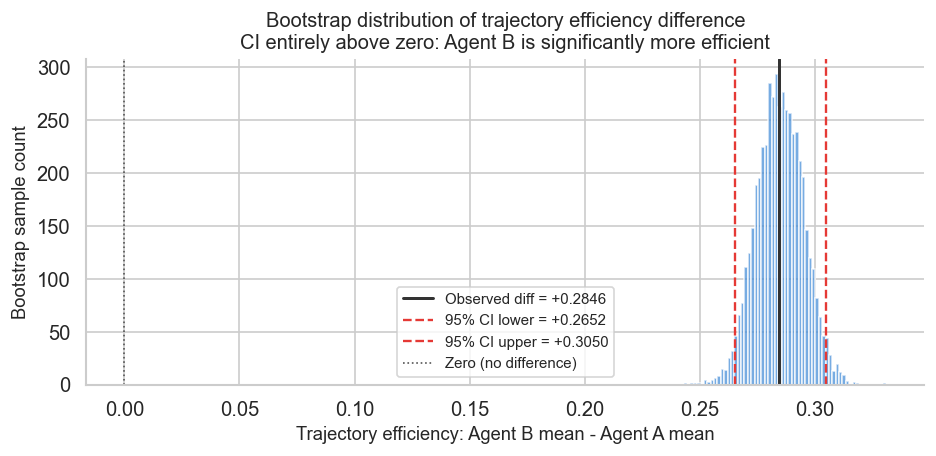

In [8]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# This chart makes the bootstrap CI visual. The key pedagogical point:
# - The black line (observed diff) is where we are.
# - The red dashed lines (CI bounds) say how much sampling uncertainty exists.
# - The grey dotted line at zero is the null hypothesis (no difference).
# - If the CI doesn't cross zero, the evidence is strong.
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the histogram of 5000 bootstrap differences
# WHY 60 bins: enough granularity to see the bell shape without over-smoothing
# for N=5000 samples
ax.hist(boot_diffs, bins=60, color=AGENT_B_COLOR, alpha=0.75, edgecolor='white')

# Observed difference: solid black line, "this is where the data lands"
ax.axvline(observed_diff, color='#333', linewidth=1.8, linestyle='-',
           label=f'Observed diff = {observed_diff:+.4f}')

# CI bounds: red dashed lines, "this is the range of plausible true differences"
ax.axvline(ci_low, color='#E53935', linewidth=1.4, linestyle='--',
           label=f'95% CI lower = {ci_low:+.4f}')
ax.axvline(ci_high, color='#E53935', linewidth=1.4, linestyle='--',
           label=f'95% CI upper = {ci_high:+.4f}')

# Zero line: grey dotted, "this is what 'no difference' looks like"
# If both CI bounds are to the right of this line, the difference is significant.
ax.axvline(0, color='#555', linewidth=1.0, linestyle=':',
           label='Zero (no difference)')

ax.set_xlabel('Trajectory efficiency: Agent B mean - Agent A mean')
ax.set_ylabel('Bootstrap sample count')
ax.set_title('Bootstrap distribution of trajectory efficiency difference\n'
             'CI entirely above zero: Agent B is significantly more efficient', fontsize=12)
ax.legend(fontsize=9)

# What to look for:
# 1. The entire distribution is to the right of zero: all 5000 bootstrap
#    samples show Agent B is more efficient (not just the observed data point)
# 2. The CI is narrow relative to the observed difference: the small sampling
#    uncertainty means the result is robust to which 200 tasks we happened to sample
# 3. The distribution is approximately bell-shaped, as expected for a mean
#    difference at N=200 (CLT in action)

plt.tight_layout()
plt.show()

---

## Section 4: The benchmark-production gap

- Benchmark performance systematically overestimates production performance: benchmarks run in ideal conditions (fast APIs, no timeouts, unlimited context, no rate limits), while production constraints shift by time of day, provider health, and task complexity. Brute-force agents (many steps, broad tool calls, frequent retries) are far more exposed to this gap than agents with efficient, targeted trajectories.
- **The chart that settles the argument**: Agent A drops from 84.5% to 70.5% under production constraints (14 points, p = 0.0004); Agent B drops from 81.5% to 79.5% (2 points). The ranking flips in this simulation: Agent B (79.5%) beats Agent A (70.5%). The size of the drop follows from the penalties coded into the simulation, so it illustrates the mechanism and does not measure a field effect.

---

### Three production constraints simulated

- **Tool latency**: response times vary (200ms at noon, 1,800ms at peak); every redundant tool call is another latency draw. Tied to trajectory efficiency below a 0.70 floor: Agent A (~0.52) is hit hard, Agent B (~0.80) is essentially immune.
- **Task timeout**: hard wall-clock limits. Agent A's 4–8 step distribution puts most tasks above a 6-step threshold; Agent B's 2–5 step distribution rarely crosses it.
- **Context window overflow**: longer trajectories accumulate more tokens; once the window fills, the agent loses earlier observations and makes planning errors. Agent A's high step count means many tasks overflow; Agent B's almost never do.

> Trajectory length and inefficiency is the property behind all three constraints, and the metric most predictive of production resilience. These problems compound in the field, so degradation there often exceeds this independent-constraint simulation. Worth adding: tool unavailability, authentication failures, input length limits, concurrent load, model version drift.

In [9]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# This function applies three independent production penalties on top of
# the benchmark task records. It does NOT modify the original DataFrames:
# it operates on copies, so we can compare benchmark vs production side by side.
#
# Design principle: each constraint's intensity is a function of trajectory
# inefficiency / step count. This is the mechanism that separates a fragile
# agent from a robust one: the agent with long, wandering trajectories (Agent A)
# gets hit hard, while the efficient agent (Agent B) barely moves. Production
# failures are not binary switches: they are probability distributions over
# task outcomes driven by how the agent behaves.
# ─────────────────────────────────────────────────────────────────────────────

def apply_production_constraints(agent_df, agent_name):
    """
    Simulate production penalties on top of benchmark task records.

    Parameters
    ----------
    agent_df : pd.DataFrame
        Benchmark task records for one agent. Must contain:
        trajectory_efficiency, num_steps, final_answer_quality, task_success.
    agent_name : str
        Used for logging/debugging only.

    Returns
    -------
    pd.DataFrame
        Modified copy of agent_df with production-adjusted task_success
        and final_answer_quality values.
    """
    df_prod = agent_df.copy()  # CRITICAL: work on a copy, never modify the original

    # ── Constraint 1: Tool latency ─────────────────────────────────────────────
    # Model: inefficient trajectories accumulate wasted, exploratory tool calls.
    # Each wasted call is an extra API round-trip under variable latency, and the
    # more an agent wanders off the optimal path, the higher the cumulative
    # latency and the higher the chance of breaching a per-task latency budget.
    #
    # WHY tie this to trajectory_efficiency?
    # Latency is driven by HOW MANY redundant round-trips an agent makes, which is
    # what trajectory efficiency measures. We penalize only the
    # *inefficiency below a 0.70 floor*: an efficient agent (efficiency >= 0.70)
    # makes few wasted calls and incurs almost no latency risk, while a
    # brute-force agent (efficiency ~0.52) racks up exploratory calls and is hit
    # hard. This is the lever that makes Agent A fragile and Agent B robust.
    #
    # Implementation: prob = max(0, 0.70 - trajectory_efficiency) * 0.42, capped
    # at 25%. An efficient agent (efficiency >= 0.70) has ~0% latency risk.
    inefficiency = np.clip(0.70 - df_prod['trajectory_efficiency'], 0, None)
    latency_failure_prob = np.clip(inefficiency * 0.42, 0, 0.25)
    latency_failures = np.random.binomial(1, latency_failure_prob)
    # Agent A's low trajectory_efficiency (~0.52) means ~7-8% latency risk per task
    # Agent B's high efficiency (~0.80) means ~0% latency risk, since it never wanders

    # ── Constraint 2: Timeout ──────────────────────────────────────────────────
    # Model: agents with >= 6 steps per task frequently exceed a 30-second wall
    # clock budget. The 6-step threshold is calibrated to a typical enterprise
    # API gateway timeout. Tasks below 6 steps have a residual 2% failure rate
    # (from external factors: network blips, cold starts, etc.).
    #
    # WHY a step threshold rather than a continuous model?
    # Timeout budgets are hard limits, not probabilities. An agent either
    # fits within the budget or it does not. The 22% failure rate above the
    # threshold reflects that some 6+ step tasks will complete just under the
    # wire, while others will time out.
    timeout_failure_prob = np.where(df_prod['num_steps'] >= 6, 0.22, 0.02)
    timeout_failures = np.random.binomial(1, timeout_failure_prob)
    # Agent A: ~55-60% of its tasks have num_steps >= 6 (heavy exposure)
    # Agent B: ~0% of its tasks have num_steps >= 6 (no exposure)

    # ── Constraint 3: Context window overflow ───────────────────────────────────
    # Model: tasks with num_steps >= 7 accumulate enough context (intermediate
    # observations, tool results, retry logs) to overflow a typical 8K token
    # context window. When this happens, the agent cannot see its earliest
    # observations and makes planning errors, degrading final answer quality.
    #
    # WHY a quality penalty instead of a failure?
    # Context overflow is a soft failure: the agent continues to execute but
    # with degraded information. It produces an answer, but the answer quality
    # drops because the agent is working with incomplete context.
    # The 0.65 multiplier = a 35% quality degradation from context overflow.
    context_overflow = df_prod['num_steps'] >= 7
    df_prod.loc[context_overflow, 'final_answer_quality'] *= 0.65
    # Agent A: ~40-45% of tasks have num_steps >= 7 (heavy exposure)
    # Agent B: ~0% of tasks have num_steps >= 7 (essentially no exposure)

    # ── Apply hard failures ────────────────────────────────────────────────────
    # A task fails in production if EITHER latency OR timeout triggers.
    # WHY OR not AND: a single hard constraint is sufficient to fail a task.
    # You don't need both the API to time out AND the context to overflow;
    # hitting either one is enough for a failed task from the user's perspective.
    hard_fail = (latency_failures == 1) | (timeout_failures == 1)
    df_prod.loc[hard_fail, 'task_success'] = 0

    n_failed = hard_fail.sum()
    print(f'  {agent_name}: {n_failed} tasks failed under production constraints '
          f'({n_failed/len(df_prod):.1%} failure rate from constraints)')
    print(f'    Context overflow affected: {context_overflow.sum()} tasks '
          f'({context_overflow.sum()/len(df_prod):.1%})')

    return df_prod


# Reset seed before applying constraints to ensure reproducibility
# WHY reset here: we want the production constraint simulation to produce
# the same random failures every time the notebook is run. Without this,
# students who re-run Section 4 without re-running Section 1 would get
# different production results.
np.random.seed(42)

print('Applying production constraints...')
agent_a_prod = apply_production_constraints(agent_a.copy(), 'Agent A')
agent_b_prod = apply_production_constraints(agent_b.copy(), 'Agent B')

# ── Benchmark vs production success rates ─────────────────────────────────────
# Build the comparison table: benchmark rate, production rate, and the drop.
# The "drop" is the key number: it quantifies how much each agent's performance
# degrades when moved from ideal to production conditions.
results = pd.DataFrame({
    'Agent': ['Agent A', 'Agent B'],
    'Benchmark success rate': [
        agent_a['task_success'].mean(),
        agent_b['task_success'].mean()
    ],
    'Production success rate': [
        agent_a_prod['task_success'].mean(),
        agent_b_prod['task_success'].mean()
    ],
})
results['Drop (pp)'] = (
    (results['Benchmark success rate'] - results['Production success rate']) * 100
).round(1)

print('\n=== Benchmark vs production success rates ===')
print(results.to_string(index=False))
print()
print('KEY INSIGHT: The agent that "won" the benchmark collapses in production,')
print('while the efficient agent holds steady, and the ranking flips.')
print('Agent A was optimized for the conditions that benchmarks provide (unlimited time,')
print('no latency variance, no step limits). Those conditions do not exist in production.')
print('Agent B never wandered, so the production constraints have almost nothing to bite on.')

# ── Statistical test: is the production drop significant? ──────────────────────
# WHY test the drop for each agent separately?
# We want to know not just "which agent is better in production" but also
# "is each agent's production performance significantly different from its
# benchmark performance?" If Agent A's drop is significant and Agent B's is not,
# that tells us Agent A is fragile (sensitive to production constraints) while
# Agent B is robust (stable across conditions).
count_bench_a = int(agent_a['task_success'].sum())
count_prod_a  = int(agent_a_prod['task_success'].sum())

# One-sided test: H1 = benchmark rate > production rate (we expect production to be worse)
z_a, p_a = proportions_ztest(
    [count_bench_a, count_prod_a], [N, N], alternative='larger')

count_bench_b = int(agent_b['task_success'].sum())
count_prod_b  = int(agent_b_prod['task_success'].sum())

z_b, p_b = proportions_ztest(
    [count_bench_b, count_prod_b], [N, N], alternative='larger')

print('\n=== Statistical test: is the benchmark-to-production drop significant? ===')
print('(Unpaired two-proportion z-test. The same 200 tasks appear in both conditions, so a paired McNemar test follows below.)')
print(f'Agent A: z = {z_a:.3f}, p = {p_a:.4f}.',
      'Significant drop (p < 0.05): Agent A is FRAGILE' if p_a < 0.05 else 'No significant drop')
print(f'Agent B: z = {z_b:.3f}, p = {p_b:.4f}.',
      'Significant drop (p < 0.05): Agent B is also impacted' if p_b < 0.05 else 'No significant drop at n = 200 (weak evidence of robustness)')
print()
from statsmodels.stats.contingency_tables import mcnemar

def paired_drop_test(bench, prod):
    b_ = int(((bench == 1) & (prod == 0)).sum())
    c_ = int(((bench == 0) & (prod == 1)).sum())
    res = mcnemar([[0, b_], [c_, 0]], exact=True)
    return b_, c_, res.pvalue

print('\n=== Paired test (McNemar binomial test, same tasks in both conditions) ===')
for _name, _bench, _prod in [('Agent A', agent_a, agent_a_prod), ('Agent B', agent_b, agent_b_prod)]:
    _b, _c, _p = paired_drop_test(_bench['task_success'].values, _prod['task_success'].values)
    print(f'{_name}: success to failure on {_b} tasks, failure to success on {_c} tasks, McNemar p = {_p:.4g}')

print()
print('Summary: Agent A shows a large, statistically significant production gap under both tests.')
print("Agent B's drop is small and not statistically significant in the unpaired test. At n = 200")
print('a non-significant drop is weak evidence of robustness and cannot confirm that production matches benchmark.')


Applying production constraints...
  Agent A: 42 tasks failed under production constraints (21.0% failure rate from constraints)
    Context overflow affected: 86 tasks (43.0%)
  Agent B: 5 tasks failed under production constraints (2.5% failure rate from constraints)
    Context overflow affected: 0 tasks (0.0%)

=== Benchmark vs production success rates ===
  Agent  Benchmark success rate  Production success rate  Drop (pp)
Agent A                   0.845                    0.705       14.0
Agent B                   0.815                    0.795        2.0

KEY INSIGHT: The agent that "won" the benchmark collapses in production,
while the efficient agent holds steady, and the ranking flips.
Agent A was optimized for the conditions that benchmarks provide (unlimited time,
no latency variance, no step limits). Those conditions do not exist in production.
Agent B never wandered, so the production constraints have almost nothing to bite on.

=== Statistical test: is the benchmark-to-pro

### The benchmark-production gap chart

- **Left (task success rate)**: drop arrows show each agent's fall under production constraints. Agent A's ~14-point drop is large and significant (z = 3.353, p = 0.0004); Agent B's ~2-point drop is small and not significant in the unpaired test (the paired McNemar test is printed in the cell above). At n = 200 a non-significant drop is weak evidence of robustness: the data are consistent with Agent B holding up but cannot confirm it.
- **Right (final answer quality)**: context overflow hits Agent A's answer quality too. Tasks with 7+ steps (nearly half of Agent A's, almost none of Agent B's) take a 35% quality penalty on overflow. Agent A's Section 2 lead evaporates; Agent B's stays unchanged.

> Agent A's 14-point drop is roughly 7x Agent B's 2-point drop. The benchmark winner becomes the production loser and the ranking flips. The gap is structural: benchmarks measure what agents can do under ideal conditions, production measures what they do once those conditions are gone.

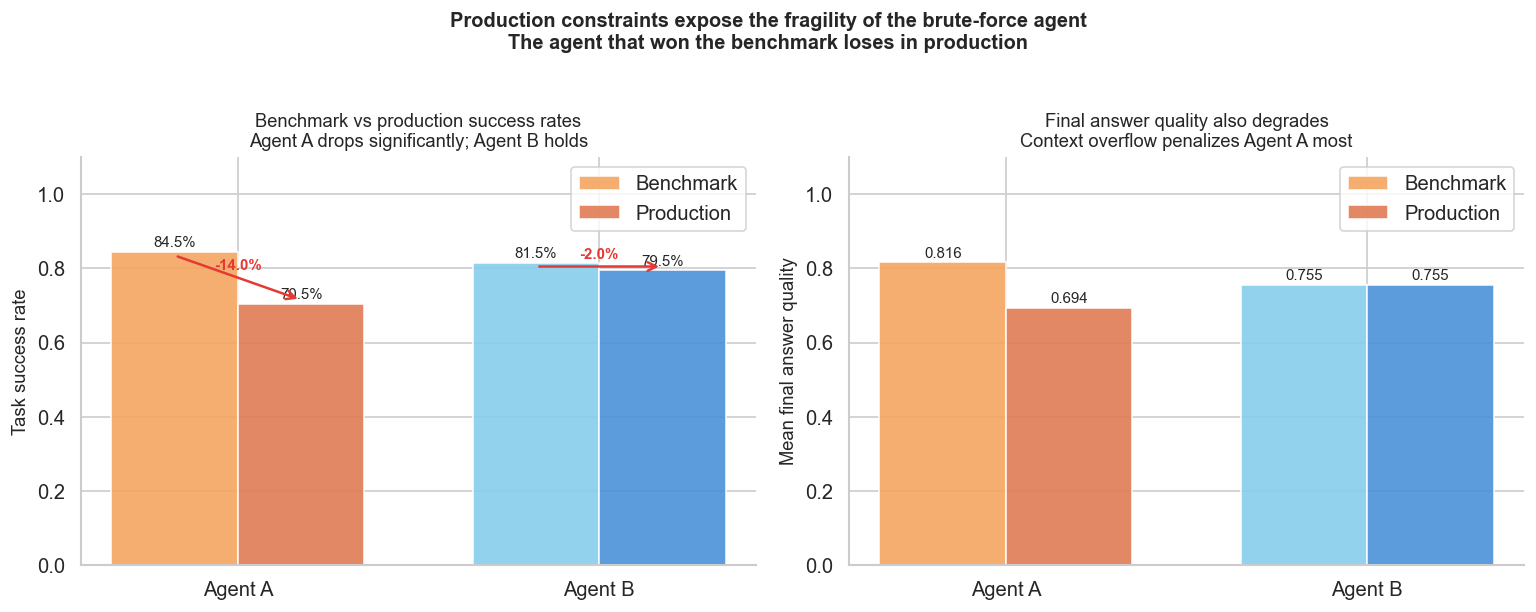

In [10]:
# ── RATIONALE ───────────────────────────────────────────────────────────────
# Two paired bar charts showing benchmark vs production performance.
# The annotated arrows communicate the DROP in performance: the number that
# matters most. We annotate drops in red to make them visually prominent;
# red conventionally signals a performance regression.
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left chart: Benchmark vs production task success rates ────────────────────
ax = axes[0]
agents = ['Agent A', 'Agent B']
bench_rates = results['Benchmark success rate'].values
prod_rates  = results['Production success rate'].values

x = np.arange(len(agents))
width = 0.35

# Lighter/muted colors for benchmark bars: these represent "ideal world" performance
# Darker/saturated colors for production bars: these represent reality
# WHY this color convention: muted = aspirational, saturated = production.
# The visual contrast reinforces that production performance is what matters.
b1 = ax.bar(x - width/2, bench_rates, width, color=['#F4A460', '#87CEEB'],
            alpha=0.9, label='Benchmark', edgecolor='white')
b2 = ax.bar(x + width/2, prod_rates, width, color=[AGENT_A_COLOR, AGENT_B_COLOR],
            alpha=0.9, label='Production', edgecolor='white')

# Add precise percentage labels above each bar
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)

# Annotate the drop with red arrows: visually shows the direction and magnitude
# of the performance regression from benchmark to production
for i, (br, pr) in enumerate(zip(bench_rates, prod_rates)):
    drop = br - pr
    # Arrow goes from benchmark bar top (source) down to production bar top (target)
    ax.annotate('', xy=(x[i] + width/2, pr + 0.01),
                xytext=(x[i] - width/2, br - 0.01),
                arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.5))
    # Label the drop magnitude between the two bars
    ax.text(x[i], (br + pr)/2 + 0.02, f'-{drop:.1%}',
            ha='center', fontsize=9, color='#E53935', fontweight='bold')
    # What to look for: Agent A's drop label is significantly larger than Agent B's.
    # The ratio of the two drops is the key evidence for Agent B's production robustness.

ax.set_xticks(x)
ax.set_xticklabels(agents)
ax.set_ylim(0, 1.10)
ax.set_ylabel('Task success rate')
ax.set_title('Benchmark vs production success rates\nAgent A drops significantly; Agent B holds', fontsize=11)
ax.legend()

# ── Right chart: Final answer quality: benchmark vs production ────────────────
# Context window overflow degrades answer quality for high-step tasks.
# This chart shows that Agent A pays a quality penalty in production, not just
# a success rate penalty.
ax2 = axes[1]

faq_bench_a = agent_a['final_answer_quality'].mean()
faq_prod_a  = agent_a_prod['final_answer_quality'].mean()
faq_bench_b = agent_b['final_answer_quality'].mean()
faq_prod_b  = agent_b_prod['final_answer_quality'].mean()

faq_bench = [faq_bench_a, faq_bench_b]
faq_prod  = [faq_prod_a, faq_prod_b]

b3 = ax2.bar(x - width/2, faq_bench, width, color=['#F4A460', '#87CEEB'],
             alpha=0.9, label='Benchmark', edgecolor='white')
b4 = ax2.bar(x + width/2, faq_prod,  width, color=[AGENT_A_COLOR, AGENT_B_COLOR],
             alpha=0.9, label='Production', edgecolor='white')

for bar in b3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in b4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(agents)
ax2.set_ylim(0, 1.10)
ax2.set_ylabel('Mean final answer quality')
ax2.set_title('Final answer quality also degrades\nContext overflow penalizes Agent A most', fontsize=11)
ax2.legend()
# What to look for:
# - Agent A, which "won" on answer quality in Section 2, now shows a visible
#   quality drop in production. Its benchmark advantage evaporates.
# - Agent B's answer quality is nearly identical in benchmark and production,
#   because almost none of its tasks overflow the context budget.
# - In production, Agent B wins on BOTH success rate AND answer quality.

plt.suptitle('Production constraints expose the fragility of the brute-force agent\n'
             'The agent that won the benchmark loses in production',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Section 5: Key takeaways

> Ask before presenting: "Who would still ship Agent A?" Some systems (medical diagnosis, legal review) can't tolerate quality loss; the answer is "it depends on your constraint," not "I never looked at trajectory metrics."

### 1. Never evaluate agents on final answer alone

Build a metric table with at least four columns: task completion, tool selection accuracy, trajectory efficiency, final answer quality. Never report a single number as the agent's "score."

### 2. Trajectory-level metrics catch process failures final-answer metrics miss

A ~28-point gap in trajectory efficiency predicts operational cost, latency, and failure-under-constraint far better than a 6-point gap in final answer quality. **Cost translation**: Agent A averages ~6 steps per task against Agent B's 3.5 (1.7x as many); its 0.52 efficiency means nearly double the optimal step count. At $0.01/API call and 10,000 tasks/day, that surplus costs roughly $250/day.

### 3. Always test under production constraints

Model at minimum:
- **Latency variation**: tools respond in 50ms to 2,000ms, not instantly
- **Timeouts**: multi-step agents blow past wall-clock budgets regularly
- **Context limits**: long trajectories force truncation or failure
- **Tool unavailability**: disable a tool for a fraction of tasks, measure the success-rate drop

Build the production eval harness before you ship, not after.

### 4. Agent benchmarks systematically overestimate production performance

The gap is structural: benchmarks optimize for coverage and measurability, production for reliability and throughput. Here, the benchmark winner (Agent A, 84.5%) becomes the production loser (70.5%, behind Agent B's 79.5%). The size of this gap comes from the penalties coded into the simulation, so it illustrates the mechanism. Measure the gap on your own traces.

### 5. The decision framework: which agent do you ship?

| Scenario | Ship Agent A (brute force) | Ship Agent B (efficient) |
|---|---|---|
| Quality is legally required to be near-perfect | Yes | Only if quality is acceptable |
| You have unlimited API budget and no timeouts | Yes (though wasteful) | Yes |
| You operate under API rate limits or cost constraints | No, Agent A will exceed budget | Yes |
| You need consistent performance across load levels | No, Agent A degrades under load | Yes |
| You need an auditable, explainable decision trail | No, extra steps = noisy trail | Yes, clean trajectory is auditable |
| You are in early prototype stage, no production SLA yet | Either is fine | Either is fine |

For most production systems at scale, Agent B is the right choice: the 6-point answer-quality gap is manageable, the cost, latency, and fragility gap is structural and grows with scale. Under production constraints, Agent B doesn't just close that gap, it overtakes Agent A on success rate.

### Evaluation taxonomy: summary reference

| Evaluation type | What it measures | When it fails without warning |
|---|---|---|
| Task-based | Goal completion rate | Agent completes task via unexpected, unmaintainable path |
| Tool use | Decision quality per step | Agent uses correct tools but in wrong order |
| Trajectory | Path quality and efficiency | Correct final state reached via detour |
| Multi-agent attribution | Which agent in a pipeline caused an outcome | Coordination failures blamed on wrong component |
| Production stress | Performance under realistic constraints | Benchmark winner collapses under load, latency, or context limits |

**Exercises to assign after this notebook**:

1. **Modify the simulation** (beginner): change Agent A's `trajectory_efficiency` mean to 0.79 (matching Agent B's). Does that close the production gap? Why or why not?
2. **Add a fourth production constraint** (intermediate): 10% of tasks lose a critical tool at random. High-step agents that depend on it more should fail more often, implement it and quantify the added gap.
3. **Design a weighted score** (advanced): build a composite score that weights the four metrics by production priorities (a customer support agent with a 30s timeout, $0.02/call cost, 8K context window, say). Show that the weighted score ranks the agents the same way the production simulation does.
4. **Field data exercise** (advanced): pull agent traces from LangSmith, Langfuse, or Phoenix, compute the four metrics used in this notebook, and compare the results to your team's current benchmark metrics.

---

**Course**: *Statistical Testing for LLM Evaluations*
**Subtitle**: *Design experiments that catch the improvements worth shipping*
**Instructor**: Rudrendu Paul, O'Reilly
**Notebook**: 04 of 04, Agent Evaluation Mini-Case